In [3]:
import pandas as pd
import numpy as np
import statsmodels

print("Python works!")
print("Pandas version:", pd.__version__)

Python works!
Pandas version: 3.0.5


In [4]:
import pandas as pd

df = pd.read_stata("../data/raw/Uzbekistan-2024-full-data.dta")

print(df.shape)

(1008, 340)


In [5]:
df.head()


,idstd,id,a4a,a6a,a2,a1c,a0,a3a,a6c,a7,...,a3,d1a2_v4,stratificationregioncode,stratificationsizecode,stratificationsectorcode,stratificationpanelcode,wstrict,wmedian,wweak,strata
0,1372275,2,Food,Small,East,Establishment,Manufacturing,East,12,No,...,50.000 to 250.000,1061,East,Small (5-19),Food,Panel,21.101807,26.549549,42.161896,202
1,1372276,6,Other Manufacturing,Medium,Center,Establishment,Manufacturing,Center,30,No,...,50.000 to 250.000,1702,Center,Medium (20-99),Other Manufacturing,Panel,55.521236,66.269096,67.648705,63
2,1372277,7,Other Manufacturing,Small,East,Establishment,Manufacturing,East,5,No,...,50.000 to 250.000,2220,East,Small (5-19),Other Manufacturing,Panel,89.856010,131.589737,153.120819,208
3,1372278,11,Textiles,Medium,East,Establishment,Manufacturing,East,140,No,...,Over 250.000 to 1 million,1393,East,Medium (20-99),Textiles,Panel,12.278679,21.053011,22.503181,218
4,1372279,12,Food,Medium,Central-East,Establishment,Manufacturing,Central-East,32,No,...,Over 250.000 to 1 million,2310,Central-East,Medium (20-99),Food,Panel,3.317076,4.357112,5.722478,174


In [6]:
df.columns.tolist()

['idstd',
 'id',
 'a4a',
 'a6a',
 'a2',
 'a1c',
 'a0',
 'a3a',
 'a6c',
 'a7',
 'panel',
 'a1a',
 'a14d',
 'a14m',
 'a14y',
 'a14h',
 'a14min',
 'a20y',
 'a20m',
 'a20d',
 'a1',
 'a12',
 'a7a',
 'a7b',
 'a11',
 'a7c',
 'a9',
 'b1',
 'b1x',
 'b1_UZB',
 'b3a',
 'b2a',
 'b2b',
 'b2c',
 'b2d',
 'b4',
 'b4a',
 'b5',
 'b6',
 'b6b',
 'b7',
 'b7a',
 'b8',
 'b8x',
 'c3',
 'c4',
 'c5',
 'c31',
 'c32',
 'c6',
 'c7',
 'c8a',
 'c8b',
 'c9a',
 'c9b',
 'c10',
 'c11',
 'c12',
 'c13',
 'c14',
 'c33',
 'c34',
 'c34b',
 'c34bx',
 'c152',
 'c162',
 'c172',
 'c35a',
 'c35b',
 'c22b',
 'c36',
 'c37',
 'c38',
 'c39',
 'c40a',
 'c40b',
 'c41a',
 'c41b',
 'c42',
 'c30a',
 'd1a1a',
 'd1a6a',
 'd1a6b',
 'd1a6c',
 'd1a6cx',
 'd1a3',
 'd2',
 'd2x',
 'n3',
 'n3x',
 'd3a',
 'd3b',
 'd3c',
 'd31x',
 'd32',
 'd4a',
 'd4b',
 'd33a',
 'd33b',
 'd342',
 'd342b',
 'd35',
 'd8',
 'd12a',
 'd12b',
 'd13',
 'd38x',
 'd39',
 'd14a',
 'd14b',
 'd40a',
 'd40b',
 'd412',
 'd412b',
 'd30a',
 'd30b',
 'o1',
 'o2',
 'o3a2',
 'o3b2',

In [7]:
df[['a6a']].value_counts().sort_index()

a6a   
Small     404
Medium    303
Large     301
Name: count, dtype: int64

In [8]:
[x for x in df.columns if 'l1' in x.lower()]

['l1', 'l10', 'l11a', 'l11a1', 'l11b', 'l11b1', 'l12a', 'l12a1', 'l1a']

In [9]:
df[['l1', 'l10', 'l11a', 'l11b', 'l12a']].head(10)

,l1,l10,l11a,l11b,l12a
0,12,No,NaN,NaN,NaN
1,30,No,NaN,NaN,NaN
2,15,No,NaN,NaN,NaN
3,60,No,NaN,NaN,NaN
4,32,No,NaN,NaN,NaN
5,6,No,NaN,NaN,NaN
6,5,No,NaN,NaN,NaN
7,12,No,NaN,NaN,NaN
8,60,No,NaN,NaN,NaN
9,18,No,NaN,NaN,NaN


In [10]:
df['l1'].describe()


count     1008
unique     209
top          5
freq       112
Name: l1, dtype: int64

In [11]:
df['l1'].attrs

{}

In [12]:
df[['d2']].head(10)


,d2
0,740000000.0
1,125000000.0
2,3312829000.0
3,21400000000.0
4,7000000000.0
5,450000000.0
6,120000000.0
7,6000000000.0
8,40000000.0
9,6000000000.0


In [13]:
df['productivity'] = df['d2'] / df['l1']

df['productivity'].describe()

TypeError: unsupported operand type(s) for /: 'Categorical' and 'Categorical'

In [ ]:
df['d2_num'] = pd.to_numeric(df['d2'].astype(str), errors='coerce')
df['l1_num'] = pd.to_numeric(df['l1'].astype(str), errors='coerce')

In [ ]:
df[['d2_num', 'l1_num']].head()

,d2_num,l1_num
0,7.400000e+08,12.0
1,1.250000e+08,30.0
2,3.312829e+09,15.0
3,2.140000e+10,60.0
4,7.000000e+09,32.0


In [ ]:
df[['d2_num', 'l1_num']].isna().sum()

d2_num    99
l1_num    26
dtype: int64

In [ ]:
df['l1_num'].value_counts().loc[lambda x: x.index == 0]

Series([], Name: l1_num, dtype: int64)

In [ ]:
df['productivity'] = df['d2_num'] / df['l1_num']
df['productivity'].describe()

count    9.000000e+02
mean     5.596238e+10
std      8.329606e+11
min      4.000000e+03
25%      2.500000e+07
50%      8.582589e+07
75%      2.694906e+08
max      2.083333e+13
Name: productivity, dtype: float64

In [ ]:
df['productivity'].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01    1.738677e+05
0.05    1.495000e+06
0.25    2.500000e+07
0.50    8.582589e+07
0.75    2.694906e+08
0.95    2.229201e+09
0.99    1.194756e+11
Name: productivity, dtype: float64

In [ ]:
df[['d2_num', 'l1_num', 'productivity']].sort_values('productivity', ascending=False).head(10)

,d2_num,l1_num,productivity
877,2.500000e+14,12.0,2.083333e+13
527,5.600000e+13,5.0,1.120000e+13
215,5.000000e+13,10.0,5.000000e+12
689,3.500000e+13,8.0,4.375000e+12
374,7.672500e+13,21.0,3.653571e+12
260,4.840900e+13,18.0,2.689389e+12
879,1.513060e+14,100.0,1.513060e+12
722,3.700000e+11,2.0,1.850000e+11
825,1.521000e+13,110.0,1.382727e+11
71,1.670000e+13,140.0,1.192857e+11


In [ ]:
df['log_productivity'] = np.log(df['productivity'])
df['log_productivity'].describe()

count    900.000000
mean      18.174109
std        2.353692
min        8.294050
25%       17.034386
50%       18.267830
75%       19.412043
max       30.667575
Name: log_productivity, dtype: float64

In [ ]:
df['l1_num'].describe()

count     982.000000
mean       93.038697
std       224.139002
min         1.000000
25%        10.000000
50%        23.000000
75%        75.000000
max      2500.000000
Name: l1_num, dtype: float64

In [ ]:
df['log_size'] = np.log(df['l1_num'])
df['log_size'].describe()

count    982.000000
mean       3.363581
std        1.402292
min        0.000000
25%        2.302585
50%        3.135494
75%        4.317488
max        7.824046
Name: log_size, dtype: float64

In [ ]:
df[['log_size', 'log_productivity']].corr()


,log_size,log_productivity
log_size,1.00000,-0.13842
log_productivity,-0.13842,1.00000


In [ ]:
from scipy.stats import pearsonr

temp = df[['log_size', 'log_productivity']].dropna()
pearsonr(temp['log_size'], temp['log_productivity'])

PearsonRResult(statistic=-0.13842027748498853, pvalue=3.0875446455431494e-05)

In [ ]:
import statsmodels.api as sm

reg_data = df[['log_productivity', 'log_size']].dropna()

X = sm.add_constant(reg_data['log_size'])
y = reg_data['log_productivity']

model_robust = sm.OLS(y, X).fit(cov_type='HC3')

print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       log_productivity   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     13.94
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           0.000201
Time:                        11:22:31   Log-Likelihood:                -2038.2
No. Observations:                 900   AIC:                             4080.
Df Residuals:                     898   BIC:                             4090.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.9601      0.215     88.020      0.0

In [ ]:
for col in df.columns:
    print(col)

idstd
id
a4a
a6a
a2
a1c
a0
a3a
a6c
a7
panel
a1a
a14d
a14m
a14y
a14h
a14min
a20y
a20m
a20d
a1
a12
a7a
a7b
a11
a7c
a9
b1
b1x
b1_UZB
b3a
b2a
b2b
b2c
b2d
b4
b4a
b5
b6
b6b
b7
b7a
b8
b8x
c3
c4
c5
c31
c32
c6
c7
c8a
c8b
c9a
c9b
c10
c11
c12
c13
c14
c33
c34
c34b
c34bx
c152
c162
c172
c35a
c35b
c22b
c36
c37
c38
c39
c40a
c40b
c41a
c41b
c42
c30a
d1a1a
d1a6a
d1a6b
d1a6c
d1a6cx
d1a3
d2
d2x
n3
n3x
d3a
d3b
d3c
d31x
d32
d4a
d4b
d33a
d33b
d342
d342b
d35
d8
d12a
d12b
d13
d38x
d39
d14a
d14b
d40a
d40b
d412
d412b
d30a
d30b
o1
o2
o3a2
o3b2
j31
r1
r2
r3
r4
r5
r6
r7
r8
r9
r10
r11
e1
e2b
e312
e6
e11
e32
e33
e34
e30
h1
h2
h32x
h5
h62x
h8
h9
f1
g6b
g2
g3
g4
g31
g32
g33
g5a
g5b
g5bx
g30a
ge3
ge3a
ge7
ge8d
k3a
k3bc
k3e
k3f
k3hd
k4
n5a
n5b
k5a
k5a1
k5i
k5i1
k5bc
k5bc1
k5e
k5e1
k5f
k5f1
k5hdj
k5hdj1
k6
k7
k82
k9
k10
k11
k13
k14a
k14b
k14c
k14d
k14e
k15a
k15b
k15c
k15d
k162
k17
k20a1
k31
k32
k21
k33
k342
k342x
k35
k36
k37
k38
k392
k392x
k40
k30
j2
j3
j4
j5
j32
j33
j34
j35
j36
j37
j38
j39
j40
j6a
j41
j42
j43
j7a
j7b
j10


In [ ]:
# Show variables related to firm characteristics and productivity controls
keywords = [
    'age', 'export', 'finance', 'internet', 'technology',
    'ownership', 'region', 'location', 'foreign', 'industry'
]

matching_vars = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print(matching_vars)

['m1a_finance_pos', 'stratificationregioncode']


In [ ]:
print(df.columns.tolist())

['idstd', 'id', 'a4a', 'a6a', 'a2', 'a1c', 'a0', 'a3a', 'a6c', 'a7', 'panel', 'a1a', 'a14d', 'a14m', 'a14y', 'a14h', 'a14min', 'a20y', 'a20m', 'a20d', 'a1', 'a12', 'a7a', 'a7b', 'a11', 'a7c', 'a9', 'b1', 'b1x', 'b1_UZB', 'b3a', 'b2a', 'b2b', 'b2c', 'b2d', 'b4', 'b4a', 'b5', 'b6', 'b6b', 'b7', 'b7a', 'b8', 'b8x', 'c3', 'c4', 'c5', 'c31', 'c32', 'c6', 'c7', 'c8a', 'c8b', 'c9a', 'c9b', 'c10', 'c11', 'c12', 'c13', 'c14', 'c33', 'c34', 'c34b', 'c34bx', 'c152', 'c162', 'c172', 'c35a', 'c35b', 'c22b', 'c36', 'c37', 'c38', 'c39', 'c40a', 'c40b', 'c41a', 'c41b', 'c42', 'c30a', 'd1a1a', 'd1a6a', 'd1a6b', 'd1a6c', 'd1a6cx', 'd1a3', 'd2', 'd2x', 'n3', 'n3x', 'd3a', 'd3b', 'd3c', 'd31x', 'd32', 'd4a', 'd4b', 'd33a', 'd33b', 'd342', 'd342b', 'd35', 'd8', 'd12a', 'd12b', 'd13', 'd38x', 'd39', 'd14a', 'd14b', 'd40a', 'd40b', 'd412', 'd412b', 'd30a', 'd30b', 'o1', 'o2', 'o3a2', 'o3b2', 'j31', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'e1', 'e2b', 'e312', 'e6', 'e11', 'e32', 'e

In [ ]:
with open("variable_list.txt", "w") as f:
    for i, col in enumerate(df.columns):
        f.write(f"{i}: {col}\n")

print("Saved variable_list.txt")

Saved variable_list.txt


In [ ]:
for i, col in enumerate(df.columns):
    if 0 <= i <= 120:
        print(i, col)

0 idstd
1 id
2 a4a
3 a6a
4 a2
5 a1c
6 a0
7 a3a
8 a6c
9 a7
10 panel
11 a1a
12 a14d
13 a14m
14 a14y
15 a14h
16 a14min
17 a20y
18 a20m
19 a20d
20 a1
21 a12
22 a7a
23 a7b
24 a11
25 a7c
26 a9
27 b1
28 b1x
29 b1_UZB
30 b3a
31 b2a
32 b2b
33 b2c
34 b2d
35 b4
36 b4a
37 b5
38 b6
39 b6b
40 b7
41 b7a
42 b8
43 b8x
44 c3
45 c4
46 c5
47 c31
48 c32
49 c6
50 c7
51 c8a
52 c8b
53 c9a
54 c9b
55 c10
56 c11
57 c12
58 c13
59 c14
60 c33
61 c34
62 c34b
63 c34bx
64 c152
65 c162
66 c172
67 c35a
68 c35b
69 c22b
70 c36
71 c37
72 c38
73 c39
74 c40a
75 c40b
76 c41a
77 c41b
78 c42
79 c30a
80 d1a1a
81 d1a6a
82 d1a6b
83 d1a6c
84 d1a6cx
85 d1a3
86 d2
87 d2x
88 n3
89 n3x
90 d3a
91 d3b
92 d3c
93 d31x
94 d32
95 d4a
96 d4b
97 d33a
98 d33b
99 d342
100 d342b
101 d35
102 d8
103 d12a
104 d12b
105 d13
106 d38x
107 d39
108 d14a
109 d14b
110 d40a
111 d40b
112 d412
113 d412b
114 d30a
115 d30b
116 o1
117 o2
118 o3a2
119 o3b2
120 j31


In [ ]:
for start in range(0, 121, 20):
    print(f"\n--- {start} to {min(start+19, 120)} ---")
    for i in range(start, min(start+20, 121)):
        print(i, df.columns[i])


--- 0 to 19 ---
0 idstd
1 id
2 a4a
3 a6a
4 a2
5 a1c
6 a0
7 a3a
8 a6c
9 a7
10 panel
11 a1a
12 a14d
13 a14m
14 a14y
15 a14h
16 a14min
17 a20y
18 a20m
19 a20d

--- 20 to 39 ---
20 a1
21 a12
22 a7a
23 a7b
24 a11
25 a7c
26 a9
27 b1
28 b1x
29 b1_UZB
30 b3a
31 b2a
32 b2b
33 b2c
34 b2d
35 b4
36 b4a
37 b5
38 b6
39 b6b

--- 40 to 59 ---
40 b7
41 b7a
42 b8
43 b8x
44 c3
45 c4
46 c5
47 c31
48 c32
49 c6
50 c7
51 c8a
52 c8b
53 c9a
54 c9b
55 c10
56 c11
57 c12
58 c13
59 c14

--- 60 to 79 ---
60 c33
61 c34
62 c34b
63 c34bx
64 c152
65 c162
66 c172
67 c35a
68 c35b
69 c22b
70 c36
71 c37
72 c38
73 c39
74 c40a
75 c40b
76 c41a
77 c41b
78 c42
79 c30a

--- 80 to 99 ---
80 d1a1a
81 d1a6a
82 d1a6b
83 d1a6c
84 d1a6cx
85 d1a3
86 d2
87 d2x
88 n3
89 n3x
90 d3a
91 d3b
92 d3c
93 d31x
94 d32
95 d4a
96 d4b
97 d33a
98 d33b
99 d342

--- 100 to 119 ---
100 d342b
101 d35
102 d8
103 d12a
104 d12b
105 d13
106 d38x
107 d39
108 d14a
109 d14b
110 d40a
111 d40b
112 d412
113 d412b
114 d30a
115 d30b
116 o1
117 o2
118 o3a2
119 o3b2


In [ ]:
# Search variable names by World Bank Enterprise Survey code patterns
for prefix in ['b', 'c', 'd', 'e', 'f', 'g', 'h', 'j', 'k', 'l', 'm']:
    matches = [col for col in df.columns if col.startswith(prefix)]
    print(prefix, ":", matches)

b : ['b1', 'b1x', 'b1_UZB', 'b3a', 'b2a', 'b2b', 'b2c', 'b2d', 'b4', 'b4a', 'b5', 'b6', 'b6b', 'b7', 'b7a', 'b8', 'b8x']
c : ['c3', 'c4', 'c5', 'c31', 'c32', 'c6', 'c7', 'c8a', 'c8b', 'c9a', 'c9b', 'c10', 'c11', 'c12', 'c13', 'c14', 'c33', 'c34', 'c34b', 'c34bx', 'c152', 'c162', 'c172', 'c35a', 'c35b', 'c22b', 'c36', 'c37', 'c38', 'c39', 'c40a', 'c40b', 'c41a', 'c41b', 'c42', 'c30a']
d : ['d1a1a', 'd1a6a', 'd1a6b', 'd1a6c', 'd1a6cx', 'd1a3', 'd2', 'd2x', 'd3a', 'd3b', 'd3c', 'd31x', 'd32', 'd4a', 'd4b', 'd33a', 'd33b', 'd342', 'd342b', 'd35', 'd8', 'd12a', 'd12b', 'd13', 'd38x', 'd39', 'd14a', 'd14b', 'd40a', 'd40b', 'd412', 'd412b', 'd30a', 'd30b', 'd1a2_v4', 'd2_num']
e : ['e1', 'e2b', 'e312', 'e6', 'e11', 'e32', 'e33', 'e34', 'e30']
f : ['f1']
g : ['g6b', 'g2', 'g3', 'g4', 'g31', 'g32', 'g33', 'g5a', 'g5b', 'g5bx', 'g30a', 'ge3', 'ge3a', 'ge7', 'ge8d']
h : ['h1', 'h2', 'h32x', 'h5', 'h62x', 'h8', 'h9', 'h30']
j : ['j31', 'j2', 'j3', 'j4', 'j5', 'j32', 'j33', 'j34', 'j35', 'j36', 'j3

In [ ]:
print(df[['b5', 'b2a', 'b2b', 'b2c', 'b2d', 'd3a', 'e1', 'e2b', 'k3a', 'k6']].describe(include='all'))

          b5   b2a   b2b   b2c   b2d   d3a  \
count   1008  1008  1008  1008  1008  1008   
unique    53    49    27    19    36    27   
top     2018   100     0     0     0   100   
freq      74   830   944   931   893   896   

                                                       e1                e2b  \
count                                                1008                953   
unique                                                  4                 34   
top     Local â main product sold mostly in same mun...  Too many to count   
freq                                                  632                674   

         k3a    k6  
count   1008  1008  
unique    25     3  
top      100   Yes  
freq     657   696  


In [ ]:
print(df.attrs)

{}


In [ ]:
print(df[['b5', 'b2a', 'b2b', 'b2c', 'b2d', 'd3a', 'e1', 'k6']].head(10).to_string())

     b5  b2a b2b b2c b2d  d3a                                                                                       e1   k6
0  2016  100   0   0   0  100  National â main product sold mostly across the country where establishment is located  Yes
1  2008  100   0   0   0  100  National â main product sold mostly across the country where establishment is located  Yes
2  2000  100   0   0   0  100  National â main product sold mostly across the country where establishment is located  Yes
3  2000  100   0   0   0   98  National â main product sold mostly across the country where establishment is located  Yes
4  2017   70   0  15  15  100   Local â main product sold mostly in same municipality where establishment is located   No
5  2017   60   0  15  25  100   Local â main product sold mostly in same municipality where establishment is located  Yes
6  2020  100   0   0   0  100   Local â main product sold mostly in same municipality where establishment is located  Yes
7  2014 

In [ ]:
df['firm_age'] = df['a20y'] - pd.to_numeric(df['b5'].astype(str), errors='coerce')

print(df['firm_age'].describe())

count    991.000000
mean      12.347124
std       11.484491
min        0.000000
25%        5.000000
50%       10.000000
75%       16.000000
max      121.000000
Name: firm_age, dtype: float64


In [ ]:
print(df['d1a2_v4'].value_counts(dropna=False))

4100    96
1410    94
1311    55
4730    32
4772    31
        ..
2391     1
2011     1
1101     1
3240     1
4761     1
Name: d1a2_v4, Length: 148, dtype: int64


In [ ]:
print(df[['d3a', 'd3b', 'd3c']].head(15).to_string())

                         d3a                       d3b                       d3c
0                        100                         0                         0
1                        100                         0                         0
2                        100                         0                         0
3                         98                         0                         2
4                        100                         0                         0
5                        100                         0                         0
6                        100                         0                         0
7                        100                         0                         0
8                        100                         0                         0
9                        100                         0                         0
10  Don't know (spontaneous)  Don't know (spontaneous)  Don't know (spontaneous)
11                       100

In [ ]:
print(df['d3a'].value_counts(dropna=False).head(15))
print()
print(df['d3b'].value_counts(dropna=False).head(15))
print()
print(df['d3c'].value_counts(dropna=False).head(15))

100                         896
80                           13
Don't know (spontaneous)     13
0                            12
60                           11
50                           10
30                            7
40                            6
10                            5
20                            4
95                            4
90                            4
70                            4
75                            2
98                            2
Name: d3a, dtype: int64

0                           937
Don't know (spontaneous)     14
20                           10
50                            8
40                            7
10                            6
25                            5
60                            4
5                             3
15                            2
70                            2
90                            2
100                           2
2                             1
3                             1
Name: d3b, dtyp

In [ ]:
print(df[['d3a', 'd3b', 'd3c']].head(20).to_string())

                         d3a                       d3b                       d3c
0                        100                         0                         0
1                        100                         0                         0
2                        100                         0                         0
3                         98                         0                         2
4                        100                         0                         0
5                        100                         0                         0
6                        100                         0                         0
7                        100                         0                         0
8                        100                         0                         0
9                        100                         0                         0
10  Don't know (spontaneous)  Don't know (spontaneous)  Don't know (spontaneous)
11                       100

In [ ]:
print(df[['d3a', 'd3b', 'd3c']].info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1008 entries, 0 to 1007
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   d3a     1008 non-null   category
 1   d3b     1008 non-null   category
 2   d3c     1008 non-null   category
dtypes: category(3)
memory usage: 14.1 KB
None


In [ ]:
df['export_status'] = (pd.to_numeric(df['d3c'].astype(str), errors='coerce') > 0).astype(int)

In [ ]:
print(df[['d3a', 'd3b', 'd3c']].columns)

Index(['d3a', 'd3b', 'd3c'], dtype='object')


In [ ]:
df['export_share'] = (
    pd.to_numeric(df['d3b'].astype(str), errors='coerce') +
    pd.to_numeric(df['d3c'].astype(str), errors='coerce')
)

print(df['export_share'].describe())

count    994.000000
mean       5.013078
std       17.987543
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      100.000000
Name: export_share, dtype: float64


In [ ]:
df['exporter'] = (df['export_share'] > 0).astype(int)

print(df['exporter'].value_counts())
print()
print(df['exporter'].value_counts(normalize=True) * 100)

0    910
1     98
Name: exporter, dtype: int64

0    90.277778
1     9.722222
Name: exporter, dtype: float64


In [ ]:
print(df['k30'].value_counts(dropna=False).sort_index())

Don't know (spontaneous)      8
No obstacle                 603
Minor obstacle              272
Moderate obstacle           100
Major obstacle               19
Very severe obstacle          6
Name: k30, dtype: int64


In [ ]:
df['finance_obstacle'] = df['k30'].map({
    'No obstacle': 0,
    'Minor obstacle': 1,
    'Moderate obstacle': 2,
    'Major obstacle': 3,
    'Very severe obstacle': 4
})

print(df['finance_obstacle'].value_counts(dropna=False).sort_index())

0.0    603
1.0    272
2.0    100
3.0     19
4.0      6
NaN      8
Name: finance_obstacle, dtype: int64


In [ ]:
print([col for col in df.columns if 'internet' in col.lower() or 'website' in col.lower()])

[]


In [ ]:
print([col for col in df.columns if col.startswith(('g', 'h', 'j', 'k'))])

['j31', 'h1', 'h2', 'h32x', 'h5', 'h62x', 'h8', 'h9', 'g6b', 'g2', 'g3', 'g4', 'g31', 'g32', 'g33', 'g5a', 'g5b', 'g5bx', 'g30a', 'ge3', 'ge3a', 'ge7', 'ge8d', 'k3a', 'k3bc', 'k3e', 'k3f', 'k3hd', 'k4', 'k5a', 'k5a1', 'k5i', 'k5i1', 'k5bc', 'k5bc1', 'k5e', 'k5e1', 'k5f', 'k5f1', 'k5hdj', 'k5hdj1', 'k6', 'k7', 'k82', 'k9', 'k10', 'k11', 'k13', 'k14a', 'k14b', 'k14c', 'k14d', 'k14e', 'k15a', 'k15b', 'k15c', 'k15d', 'k162', 'k17', 'k20a1', 'k31', 'k32', 'k21', 'k33', 'k342', 'k342x', 'k35', 'k36', 'k37', 'k38', 'k392', 'k392x', 'k40', 'k30', 'j2', 'j3', 'j4', 'j5', 'j32', 'j33', 'j34', 'j35', 'j36', 'j37', 'j38', 'j39', 'j40', 'j6a', 'j41', 'j42', 'j43', 'j7a', 'j7b', 'j10', 'j11', 'j12', 'j13', 'j14', 'j15', 'j30a', 'j30b', 'j30c', 'j30e', 'j30f', 'h30', 'j30_taxrate_pos', 'j30_taxadmin_pos', 'j30_permit_pos', 'j30_instability_pos', 'j30_corruption_pos', 'j30_courts_pos', 'j30_crime_pos']


In [ ]:
print(df[['g6b', 'g2', 'g3', 'g4', 'g31', 'g32', 'g33', 'g5a', 'g5b']].head(10).to_string())

   g6b   g2    g3   g4  g31   g32         g33                       g5a  g5b
0    0   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
1    0   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
2    0  Yes  10.0   No  Yes  20.0  28000000.0                       NaN  NaN
3    0   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
4    0   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
5    0   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
6  100   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
7    0   No   NaN  NaN   No   NaN         NaN  Don't know (spontaneous)  NaN
8  100   No   NaN  NaN   No   NaN         NaN                       NaN  NaN
9    0   No   NaN  NaN   No   NaN         NaN  Don't know (spontaneous)  NaN


In [ ]:
print(df[['c3', 'c4', 'c5', 'c31', 'c32', 'c6', 'c7', 'c8a', 'c8b', 'c9a', 'c9b',
          'c10', 'c11', 'c12', 'c13', 'c14', 'c33', 'c34', 'c34b', 'c152', 'c162', 'c172',
          'c35a', 'c35b', 'c22b']].head(10).to_string())

    c3   c4   c5                       c31    c32   c6   c7  c8a   c8b   c9a  c9b c10  c11 c12  c13  c14  c33                       c34          c34b c152 c162 c172 c35a c35b c22b
0   No  NaN  NaN                       NaN  10000   No  NaN  NaN   NaN   NaN  NaN  No  NaN  No  NaN  NaN  NaN                       500  Cubic meters   No  NaN  NaN  NaN  NaN   No
1   No  NaN  NaN                       NaN   1000   No  NaN  NaN   NaN   NaN  NaN  No  NaN  No  NaN  NaN  NaN  Don't know (spontaneous)           NaN   No  NaN  NaN  NaN  NaN   No
2  Yes  3.0   No                30000000.0  10000  Yes  3.0  0.0  30.0  None  NaN  No  NaN  No  NaN  NaN  NaN                        50  Cubic meters   No  NaN  NaN  NaN  NaN  Yes
3   No  NaN  NaN                       NaN   9000   No  NaN  NaN   NaN   NaN  NaN  No  NaN  No  NaN  NaN  NaN  Don't know (spontaneous)           NaN   No  NaN  NaN  NaN  NaN  Yes
4   No  NaN  NaN                       NaN   9500   No  NaN  NaN   NaN   NaN  NaN  No  NaN  No  NaN 

In [ ]:
print(df['c22b'].value_counts(dropna=False))

No                          648
Yes                         341
Don't know (spontaneous)     19
Name: c22b, dtype: int64


In [ ]:
lower = df['productivity'].quantile(0.01)
upper = df['productivity'].quantile(0.99)

df['productivity_winsorized'] = df['productivity'].clip(
    lower=lower,
    upper=upper
)

df['log_productivity_w'] = np.log(
    df['productivity_winsorized']
)

print("1% cutoff:", lower)
print("99% cutoff:", upper)

print("\nWinsorized log productivity:")
print(df['log_productivity_w'].describe())

In [ ]:
.\.venv\Scripts\python.exe -m pip install ipykernel

In [ ]:
import sys
print(sys.executable)

c:\Users\User\Documents\Bigger-Firms-Better-Productivity\.venv\Scripts\python.exe


In [14]:
lower = df['productivity'].quantile(0.01)
upper = df['productivity'].quantile(0.99)

df['productivity_winsorized'] = df['productivity'].clip(
    lower=lower,
    upper=upper
)

df['log_productivity_w'] = np.log(
    df['productivity_winsorized']
)

print("1% cutoff:", lower)
print("99% cutoff:", upper)

print("\nWinsorized log productivity:")
print(df['log_productivity_w'].describe())

KeyError: 'productivity'

In [15]:
df['sales'] = pd.to_numeric(df['d2'].astype(str), errors='coerce')
df['employees'] = pd.to_numeric(df['l1'].astype(str), errors='coerce')

df['productivity'] = df['sales'] / df['employees']

df.loc[
    (df['sales'] <= 0) | (df['employees'] <= 0),
    'productivity'
] = np.nan

df['productivity'].describe()

count    9.000000e+02
mean     5.596238e+10
std      8.329606e+11
min      4.000000e+03
25%      2.500000e+07
50%      8.582589e+07
75%      2.694906e+08
max      2.083333e+13
Name: productivity, dtype: float64

In [17]:
lower = df['productivity'].quantile(0.01)
upper = df['productivity'].quantile(0.99)

df['productivity_winsorized'] = df['productivity'].clip(
    lower=lower,
    upper=upper
)

df['log_productivity_w'] = np.log(
    df['productivity_winsorized']
)

print("1% cutoff:", lower)
print("99% cutoff:", upper)

print("\nWinsorized log productivity:")
print(df['log_productivity_w'].describe())


1% cutoff: 173867.65136123527
99% cutoff: 119475584415.58424

Winsorized log productivity:
count    900.000000
mean      18.153364
std        2.204769
min       12.066050
25%       17.034386
50%       18.267830
75%       19.412043
max       25.506378
Name: log_productivity_w, dtype: float64


In [18]:
productivity_by_size = df.groupby(
    'firm_size',
    observed=False
)['log_productivity_w'].agg(
    ['count', 'mean', 'median', 'std']
)

productivity_by_size

KeyError: 'firm_size'

In [20]:
df['firm_size'] = pd.cut(
    df['employees'],
    bins=[0, 4, 19, 99, float('inf')],
    labels=['Below 5', 'Small', 'Medium', 'Large']
)

print(df['firm_size'].value_counts(dropna=False))

firm_size
Small      430
Medium     331
Large      212
NaN         26
Below 5      9
Name: count, dtype: int64


In [22]:
productivity_by_size = df.groupby(
    'firm_size',
    observed=False
)['log_productivity_w'].agg(
    ['count', 'mean', 'median', 'std']
)

productivity_by_size

,count,mean,median,std
firm_size,,,,
Below 5,9,19.365826,18.980297,2.851928
Small,403,18.329278,18.204256,2.002530
Medium,309,18.215279,18.420681,2.102565
Large,179,17.589468,18.063006,2.647344


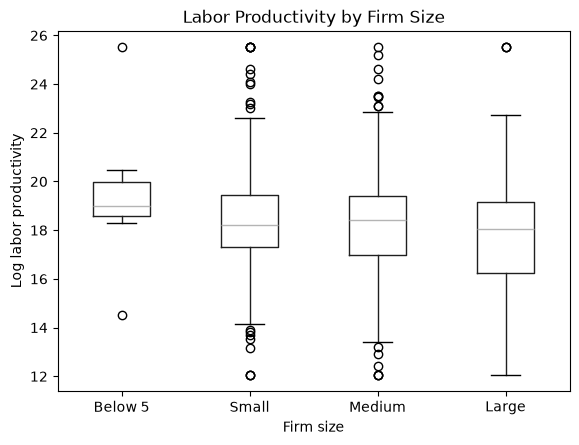

In [23]:
import matplotlib.pyplot as plt

df.boxplot(
    column='log_productivity_w',
    by='firm_size',
    grid=False
)

plt.title('Labor Productivity by Firm Size')
plt.suptitle('')
plt.xlabel('Firm size')
plt.ylabel('Log labor productivity')
plt.show()


In [25]:

productivity_reg_data = df[
    ['log_productivity_w', 'firm_size']
].dropna()

productivity_model = smf.ols(
    'log_productivity_w ~ C(firm_size)',
    data=productivity_reg_data
).fit(
    cov_type='HC1'
)

print(productivity_model.summary())

NameError: name 'smf' is not defined

In [26]:
import statsmodels.formula.api as smf

productivity_reg_data = df[
    ['log_productivity_w', 'firm_size']
].dropna()

productivity_model = smf.ols(
    'log_productivity_w ~ C(firm_size)',
    data=productivity_reg_data
).fit(
    cov_type='HC1'
)

print(productivity_model.summary())



                            OLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.303
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00504
Time:                        10:06:53   Log-Likelihood:                -1979.4
No. Observations:                 900   AIC:                             3967.
Df Residuals:                     896   BIC:                             3986.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 19

In [27]:
productivity_model = smf.ols(
    'log_productivity_w ~ C(firm_size, Treatment(reference="Small"))',
    data=productivity_reg_data
).fit(
    cov_type='HC1'
)

print(productivity_model.summary())

                            OLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.303
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00504
Time:                        10:07:16   Log-Likelihood:                -1979.4
No. Observations:                 900   AIC:                             3967.
Df Residuals:                     896   BIC:                             3986.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [28]:
productivity_controlled = df[
    [
        'log_productivity_w',
        'firm_size',
        'stratificationsectorcode',
        'stratificationregioncode'
    ]
].dropna()

productivity_model_controlled = smf.ols(
    'log_productivity_w ~ C(firm_size, Treatment(reference="Small"))'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_controlled
).fit(
    cov_type='HC1'
)

print(productivity_model_controlled.summary())

                            OLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     3.683
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.12e-06
Time:                        10:08:07   Log-Likelihood:                -1963.4
No. Observations:                 900   AIC:                             3957.
Df Residuals:                     885   BIC:                             4029.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [29]:
print(df['firm_age'].describe())
print("\nMissing:", df['firm_age'].isna().sum())

KeyError: 'firm_age'

In [30]:
[x for x in df.columns if 'age' in x.lower()]

[]

In [31]:
[x for x in df.columns if x.startswith(('b', 'c', 'd'))]

['b1',
 'b1x',
 'b1_UZB',
 'b3a',
 'b2a',
 'b2b',
 'b2c',
 'b2d',
 'b4',
 'b4a',
 'b5',
 'b6',
 'b6b',
 'b7',
 'b7a',
 'b8',
 'b8x',
 'c3',
 'c4',
 'c5',
 'c31',
 'c32',
 'c6',
 'c7',
 'c8a',
 'c8b',
 'c9a',
 'c9b',
 'c10',
 'c11',
 'c12',
 'c13',
 'c14',
 'c33',
 'c34',
 'c34b',
 'c34bx',
 'c152',
 'c162',
 'c172',
 'c35a',
 'c35b',
 'c22b',
 'c36',
 'c37',
 'c38',
 'c39',
 'c40a',
 'c40b',
 'c41a',
 'c41b',
 'c42',
 'c30a',
 'd1a1a',
 'd1a6a',
 'd1a6b',
 'd1a6c',
 'd1a6cx',
 'd1a3',
 'd2',
 'd2x',
 'd3a',
 'd3b',
 'd3c',
 'd31x',
 'd32',
 'd4a',
 'd4b',
 'd33a',
 'd33b',
 'd342',
 'd342b',
 'd35',
 'd8',
 'd12a',
 'd12b',
 'd13',
 'd38x',
 'd39',
 'd14a',
 'd14b',
 'd40a',
 'd40b',
 'd412',
 'd412b',
 'd30a',
 'd30b',
 'd1a2_v4']

In [32]:
[x for x in df.columns if x.startswith('b')]

['b1',
 'b1x',
 'b1_UZB',
 'b3a',
 'b2a',
 'b2b',
 'b2c',
 'b2d',
 'b4',
 'b4a',
 'b5',
 'b6',
 'b6b',
 'b7',
 'b7a',
 'b8',
 'b8x']

In [33]:
for col in df.columns:
    if col.startswith('b'):
        print(f"\n--- {col} ---")
        print(df[col].head(10).to_list())


--- b1 ---
['Shareholding company with non-traded shares or shares traded privately', 'Sole proprietorship', 'Shareholding company with non-traded shares or shares traded privately', 'Shareholding company with non-traded shares or shares traded privately', 'Shareholding company with non-traded shares or shares traded privately', 'Shareholding company with non-traded shares or shares traded privately', 'Shareholding company with non-traded shares or shares traded privately', 'Shareholding company with non-traded shares or shares traded privately', 'Shareholding company with non-traded shares or shares traded privately', 'Sole proprietorship']

--- b1x ---
['', '', '', '', '', '', '', '', '', '']

--- b1_UZB ---
['Limited Liability Corporation (LLC)', 'A private enterprise (PE)', 'Limited Liability Corporation (LLC)', 'Limited Liability Corporation (LLC)', 'Limited Liability Corporation (LLC)', 'Limited Liability Corporation (LLC)', 'Limited Liability Corporation (LLC)', 'Limited Liabil

In [34]:
[x for x in df.columns if any(word in x.lower() for word in ['year', 'est', 'start', 'found'])]

[]

In [35]:
[x for x in df.columns if any(word in x.lower() for word in ['year', 'est', 'start', 'found'])]

[]

In [36]:
print(df['b5'].value_counts(dropna=False).head(20))

b5
2018    74
2019    70
2017    65
2016    62
2009    52
2013    50
2015    50
2020    46
2014    43
2010    41
2021    40
2008    38
2022    38
2011    35
2007    29
2004    26
2005    23
2012    22
1994    21
2006    19
Name: count, dtype: int64


In [37]:
df['firm_age'] = 2024 - pd.to_numeric(df['b5'], errors='coerce')

print(df['firm_age'].describe())
print("\nMissing:", df['firm_age'].isna().sum())

count    991.000000
mean      13.347124
std       11.484491
min        1.000000
25%        6.000000
50%       11.000000
75%       17.000000
max      122.000000
Name: firm_age, dtype: float64

Missing: 17


In [39]:
productivity_age_data = df[
    [
        'log_productivity_w',
        'firm_size',
        'firm_age',
        'stratificationsectorcode',
        'stratificationregioncode'
    ]
].dropna()

productivity_model_age = smf.ols(
    'log_productivity_w ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_age_data
).fit(cov_type='HC1')

print(productivity_model_age.summary())

                            OLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     3.555
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.35e-06
Time:                        10:13:20   Log-Likelihood:                -1943.4
No. Observations:                 893   AIC:                             3919.
Df Residuals:                     877   BIC:                             3996.
Df Model:                          15                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [40]:
print(
    productivity_model_age.params[
        ['firm_age']
    ]
)

print(
    productivity_model_age.pvalues[
        ['firm_age']
    ]
)

firm_age   -0.001604
dtype: float64
firm_age    0.836844
dtype: float64


In [41]:
print(df[['b2a', 'b2b', 'b2c', 'b2d']].head(10))

   b2a b2b b2c b2d
0  100   0   0   0
1  100   0   0   0
2  100   0   0   0
3  100   0   0   0
4   70   0  15  15
5   60   0  15  25
6  100   0   0   0
7   75   0  15  10
8  100   0   0   0
9  100   0   0   0


In [42]:
print(df[['b2a', 'b2b', 'b2c', 'b2d']].dtypes)


b2a    category
b2b    category
b2c    category
b2d    category
dtype: object


In [43]:
for col in ['b2a', 'b2b', 'b2c', 'b2d']:
    print(col, df[col].value_counts(dropna=False).head())

b2a b2a
100                         830
0                            31
70                           22
Don't know (spontaneous)     17
80                           12
Name: count, dtype: int64
b2b b2b
0                           944
Don't know (spontaneous)     17
100                          11
20                            5
25                            3
Name: count, dtype: int64
b2c b2c
0                           931
15                           30
Don't know (spontaneous)     17
51                            5
50                            4
Name: count, dtype: int64
b2d b2d
0                           893
100                          19
Don't know (spontaneous)     17
15                           17
10                            8
Name: count, dtype: int64


In [44]:
import pyreadstat

_, meta = pyreadstat.read_dta(
    r"data/raw/Uzbekistan-2024-full-data.dta"
)

for col in ['b2a', 'b2b', 'b2c', 'b2d']:
    print(col, ":", meta.column_names_to_labels.get(col))

ModuleNotFoundError: No module named 'pyreadstat'

In [45]:
.\.venv\Scripts\python.exe -m pip install pyreadstat

SyntaxError: invalid syntax (351188673.py, line 1)

In [46]:
import pyreadstat

_, meta = pyreadstat.read_dta(
    r"data/raw/Uzbekistan-2024-full-data.dta"
)

for col in ['b2a', 'b2b', 'b2c', 'b2d']:
    print(col, ":", meta.column_names_to_labels.get(col))

PyreadstatError: File data/raw/Uzbekistan-2024-full-data.dta does not exist!

In [47]:
_, meta = pyreadstat.read_dta(
    r"../data/raw/Uzbekistan-2024-full-data.dta"
)

for col in ['b2a', 'b2b', 'b2c', 'b2d']:
    print(col, ":", meta.column_names_to_labels.get(col))

ReadstatError: Unable to convert string to the requested encoding (invalid byte sequence)

In [48]:
df['foreign_ownership'] = pd.to_numeric(
    df['b2b'].astype(str),
    errors='coerce'
)

df['foreign_owned'] = np.where(
    df['foreign_ownership'] > 0,
    1,
    np.where(df['foreign_ownership'] == 0, 0, np.nan)
)

print(df['foreign_owned'].value_counts(dropna=False))

foreign_owned
0.0    944
1.0     47
NaN     17
Name: count, dtype: int64


In [49]:
productivity_foreign_data = df[
    [
        'log_productivity_w',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'stratificationsectorcode',
        'stratificationregioncode'
    ]
].dropna()

productivity_model_foreign = smf.ols(
    'log_productivity_w ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_foreign_data
).fit(cov_type='HC1')

print(productivity_model_foreign.summary())


                            OLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     3.336
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.01e-05
Time:                        10:19:17   Log-Likelihood:                -1941.6
No. Observations:                 892   AIC:                             3917.
Df Residuals:                     875   BIC:                             3999.
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [50]:
print(
    productivity_model_foreign.params[['firm_age', 'foreign_owned']]
)

print(
    productivity_model_foreign.pvalues[['firm_age', 'foreign_owned']]
)


firm_age        -0.001428
foreign_owned    0.177548
dtype: float64
firm_age         0.854787
foreign_owned    0.631385
dtype: float64


In [51]:
print(df[['b5', 'b6', 'b6b', 'b7', 'b7a']].head(10))

     b5  b6                       b6b                b7 b7a
0  2016  10                      2016                 5  No
1  2008  20                      2008                16  No
2  2000   3                      2000                28  No
3  2000  10                      2000                30  No
4  2017  16                      2017                 9  No
5  2017   5                      2017                 8  No
6  2020   5  Don't know (spontaneous)                20  No
7  2014   6                      2014  One year or less  No
8  2007  50                      2007                15  No
9  1995   6                      1996                16  No


In [52]:
print(df[['d3a', 'd3b', 'd3c']].head(15))

                         d3a                       d3b  \
0                        100                         0   
1                        100                         0   
2                        100                         0   
3                         98                         0   
4                        100                         0   
5                        100                         0   
6                        100                         0   
7                        100                         0   
8                        100                         0   
9                        100                         0   
10  Don't know (spontaneous)  Don't know (spontaneous)   
11                       100                         0   
12                       100                         0   
13                        80                         5   
14                       100                         0   

                         d3c  
0                          0  
1        

In [53]:
print(df[['d3a', 'd3b', 'd3c']].describe(include='all'))

         d3a   d3b   d3c
count   1008  1008  1008
unique    27    19    30
top      100     0     0
freq     896   937   930


In [54]:
print(df[['d3a', 'd3b', 'd3c']].value_counts().head(20))

d3a                       d3b                       d3c                     
100                       0                         0                           896
Don't know (spontaneous)  Don't know (spontaneous)  Don't know (spontaneous)     11
80                        20                        0                             7
0                         0                         100                           6
60                        40                        0                             5
40                        60                        0                             4
20                        0                         80                            4
80                        0                         20                            3
50                        0                         50                            3
                          50                        0                             3
                          25                        25                            3

In [56]:
print(df[['d3a', 'd3b', 'd3c']].iloc[[0, 3, 13, 20, 30, 40, 50, 60, 70, 80]].to_string())


    d3a d3b d3c
0   100   0   0
3    98   0   2
13   80   5  15
20  100   0   0
30  100   0   0
40  100   0   0
50  100   0   0
60  100   0   0
70  100   0   0
80  100   0   0


In [57]:
print(df[['d3a', 'd3b', 'd3c']].dtypes)



d3a    category
d3b    category
d3c    category
dtype: object


In [58]:
df['export_share'] = (
    pd.to_numeric(df['d3b'].astype(str), errors='coerce')
    + pd.to_numeric(df['d3c'].astype(str), errors='coerce')
)

print(df['export_share'].describe())
print("\nExport share distribution:")
print(df['export_share'].value_counts().sort_index().head(20))






count    994.000000
mean       5.013078
std       17.987543
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      100.000000
Name: export_share, dtype: float64

Export share distribution:
export_share
0.0     896
2.0       2
5.0       4
7.0       2
10.0      4
15.0      2
20.0     12
25.0      2
30.0      4
31.0      1
35.0      1
40.0     11
41.0      1
50.0     10
51.0      1
57.0      1
58.0      1
60.0      6
70.0      7
75.0      2
Name: count, dtype: int64


In [59]:
df['exporter'] = np.where(
    df['export_share'] > 0,
    1,
    np.where(df['export_share'] == 0, 0, np.nan)
)

print(df['exporter'].value_counts(dropna=False))

exporter
0.0    896
1.0     98
NaN     14
Name: count, dtype: int64


In [60]:

print(df['exporter'].value_counts(dropna=False))


exporter
0.0    896
1.0     98
NaN     14
Name: count, dtype: int64


In [61]:
productivity_export_data = df[
    [
        'log_productivity_w',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'exporter',
        'stratificationsectorcode',
        'stratificationregioncode'
    ]
].dropna()

productivity_model_export = smf.ols(
    'log_productivity_w ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + exporter'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_export_data
).fit(cov_type='HC1')

print(productivity_model_export.summary())

                            OLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     3.140
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.88e-05
Time:                        10:34:17   Log-Likelihood:                -1932.5
No. Observations:                 887   AIC:                             3901.
Df Residuals:                     869   BIC:                             3987.
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [62]:
print(
    df.groupby('exporter', dropna=True)['log_productivity_w']
      .agg(['count', 'mean', 'median', 'std'])
)


          count       mean     median       std
exporter                                       
0.0         817  18.181036  18.238359  2.178894
1.0          78  17.896572  18.650847  2.509286


In [64]:
print(df['k6'].value_counts(dropna=False))



k6
Yes                         696
No                          280
Don't know (spontaneous)     32
Name: count, dtype: int64


In [65]:
print(df[['k6']].head(20).to_string())

                          k6
0                        Yes
1                        Yes
2                        Yes
3                        Yes
4                         No
5                        Yes
6                        Yes
7                         No
8                        Yes
9                         No
10                       Yes
11                       Yes
12                       Yes
13                       Yes
14                       Yes
15                       Yes
16                       Yes
17                       Yes
18  Don't know (spontaneous)
19                       Yes


In [66]:
print(df.columns.get_loc('k6'))


184


In [67]:
productivity_weighted_data = df[
    [
        'log_productivity_w',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'exporter',
        'stratificationsectorcode',
        'stratificationregioncode',
        'wmedian'
    ]
].dropna()

productivity_model_weighted = smf.wls(
    'log_productivity_w ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + exporter'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_weighted_data,
    weights=productivity_weighted_data['wmedian']
).fit()

productivity_model_weighted_robust = (
    productivity_model_weighted.get_robustcov_results(cov_type='HC1')
)

print(productivity_model_weighted_robust.summary())

                            WLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.094
Model:                            WLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     2.519
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           0.000636
Time:                        10:44:59   Log-Likelihood:                -2243.7
No. Observations:                 887   AIC:                             4523.
Df Residuals:                     869   BIC:                             4610.
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [68]:
productivity_raw_data = df[
    [
        'log_productivity',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'exporter',
        'stratificationsectorcode',
        'stratificationregioncode'
    ]
].dropna()

productivity_model_raw = smf.ols(
    'log_productivity ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + exporter'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_raw_data
).fit(cov_type='HC1')

print(productivity_model_raw.summary())

KeyError: "['log_productivity'] not in index"

In [69]:
df['log_productivity'] = np.log(df['productivity'])

print(df['log_productivity'].describe())

count    900.000000
mean      18.174109
std        2.353692
min        8.294050
25%       17.034386
50%       18.267830
75%       19.412043
max       30.667575
Name: log_productivity, dtype: float64


In [70]:
productivity_raw_data = df[
    [
        'log_productivity',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'exporter',
        'stratificationsectorcode',
        'stratificationregioncode'
    ]
].dropna()

productivity_model_raw = smf.ols(
    'log_productivity ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + exporter'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_raw_data
).fit(cov_type='HC1')

print(productivity_model_raw.summary())

                            OLS Regression Results                            
Dep. Variable:       log_productivity   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     3.065
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.91e-05
Time:                        10:46:15   Log-Likelihood:                -1990.0
No. Observations:                 887   AIC:                             4016.
Df Residuals:                     869   BIC:                             4102.
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [71]:
print(df[['wmedian', 'wstrict', 'wweak']].describe())


           wmedian      wstrict        wweak
count  1008.000000  1008.000000  1008.000000
mean     35.105545    30.540718    51.971493
std      41.906742    37.094872    64.488564
min       1.000000     1.000000     1.000000
25%       3.636106     2.807790     4.857194
50%      13.226295    10.558067    17.061198
75%      69.644691    57.141937    91.385187
max     207.384521   163.580078   288.411713


In [72]:
productivity_wstrict_data = df[
    [
        'log_productivity_w',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'exporter',
        'stratificationsectorcode',
        'stratificationregioncode',
        'wstrict'
    ]
].dropna()

productivity_model_wstrict = smf.wls(
    'log_productivity_w ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + exporter'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_wstrict_data,
    weights=productivity_wstrict_data['wstrict']
).fit()

productivity_model_wstrict_robust = (
    productivity_model_wstrict.get_robustcov_results(cov_type='HC1')
)

print(productivity_model_wstrict_robust.summary())

                            WLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.092
Model:                            WLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     2.426
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00105
Time:                        10:47:53   Log-Likelihood:                -2260.9
No. Observations:                 887   AIC:                             4558.
Df Residuals:                     869   BIC:                             4644.
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [73]:
productivity_wweak_data = df[
    [
        'log_productivity_w',
        'firm_size',
        'firm_age',
        'foreign_owned',
        'exporter',
        'stratificationsectorcode',
        'stratificationregioncode',
        'wweak'
    ]
].dropna()

productivity_model_wweak = smf.wls(
    'log_productivity_w ~ '
    'C(firm_size, Treatment(reference="Small"))'
    ' + firm_age'
    ' + foreign_owned'
    ' + exporter'
    ' + C(stratificationsectorcode)'
    ' + C(stratificationregioncode)',
    data=productivity_wweak_data,
    weights=productivity_wweak_data['wweak']
).fit()

productivity_model_wweak_robust = (
    productivity_model_wweak.get_robustcov_results(cov_type='HC1')
)

print(productivity_model_wweak_robust.summary())

                            WLS Regression Results                            
Dep. Variable:     log_productivity_w   R-squared:                       0.092
Model:                            WLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     2.379
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00135
Time:                        10:48:56   Log-Likelihood:                -2269.7
No. Observations:                 887   AIC:                             4575.
Df Residuals:                     869   BIC:                             4662.
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [74]:
results_table = pd.DataFrame({
    'Specification': [
        'Unweighted, winsorized',
        'Unweighted, raw',
        'WLS: wmedian',
        'WLS: wstrict',
        'WLS: wweak'
    ],
    'Large_vs_Small': [
        productivity_model_controlled.params[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_raw.params[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_weighted_robust.params[3],
        productivity_model_wstrict_robust.params[3],
        productivity_model_wweak_robust.params[3]
    ]
})

print(results_table)


            Specification  Large_vs_Small
0  Unweighted, winsorized       -0.715108
1         Unweighted, raw       -0.863780
2            WLS: wmedian       -1.099103
3            WLS: wstrict       -1.131747
4              WLS: wweak       -1.032076


In [75]:
robustness_table = pd.DataFrame({
    'Specification': [
        'Unweighted, winsorized',
        'Unweighted, raw',
        'WLS: wmedian',
        'WLS: wstrict',
        'WLS: wweak'
    ],
    'Coefficient': [
        productivity_model_controlled.params[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_raw.params[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_weighted_robust.params[3],
        productivity_model_wstrict_robust.params[3],
        productivity_model_wweak_robust.params[3]
    ],
    'P_value': [
        productivity_model_controlled.pvalues[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_raw.pvalues[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_weighted_robust.pvalues[3],
        productivity_model_wstrict_robust.pvalues[3],
        productivity_model_wweak_robust.pvalues[3]
    ]
})

print(robustness_table.round(4))

            Specification  Coefficient  P_value
0  Unweighted, winsorized      -0.7151   0.0024
1         Unweighted, raw      -0.8638   0.0007
2            WLS: wmedian      -1.0991   0.0015
3            WLS: wstrict      -1.1317   0.0012
4              WLS: wweak      -1.0321   0.0028


In [76]:
robustness_final = pd.DataFrame({
    'Specification': [
        'Unweighted, winsorized',
        'Unweighted, raw',
        'WLS: wmedian',
        'WLS: wstrict',
        'WLS: wweak'
    ],
    'Coefficient': [
        productivity_model_controlled.params[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_raw.params[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_weighted_robust.params[3],
        productivity_model_wstrict_robust.params[3],
        productivity_model_wweak_robust.params[3]
    ],
    'Std_Error': [
        productivity_model_controlled.bse[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_raw.bse[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_weighted_robust.bse[3],
        productivity_model_wstrict_robust.bse[3],
        productivity_model_wweak_robust.bse[3]
    ],
    'P_value': [
        productivity_model_controlled.pvalues[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_raw.pvalues[
            'C(firm_size, Treatment(reference="Small"))[T.Large]'
        ],
        productivity_model_weighted_robust.pvalues[3],
        productivity_model_wstrict_robust.pvalues[3],
        productivity_model_wweak_robust.pvalues[3]
    ],
    'N': [
        int(productivity_model_controlled.nobs),
        int(productivity_model_raw.nobs),
        int(productivity_model_weighted_robust.nobs),
        int(productivity_model_wstrict_robust.nobs),
        int(productivity_model_wweak_robust.nobs)
    ]
})

print(robustness_final.round(4))

            Specification  Coefficient  Std_Error  P_value    N
0  Unweighted, winsorized      -0.7151     0.2358   0.0024  900
1         Unweighted, raw      -0.8638     0.2551   0.0007  887
2            WLS: wmedian      -1.0991     0.3448   0.0015  887
3            WLS: wstrict      -1.1317     0.3490   0.0012  887
4              WLS: wweak      -1.0321     0.3442   0.0028  887
